In [17]:
# 1. Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Load your actual preprocessed Mall_Customers data
df = pd.read_csv('/content/drive/MyDrive/UzmaFatima_ML_Internship/Mall_Customers.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


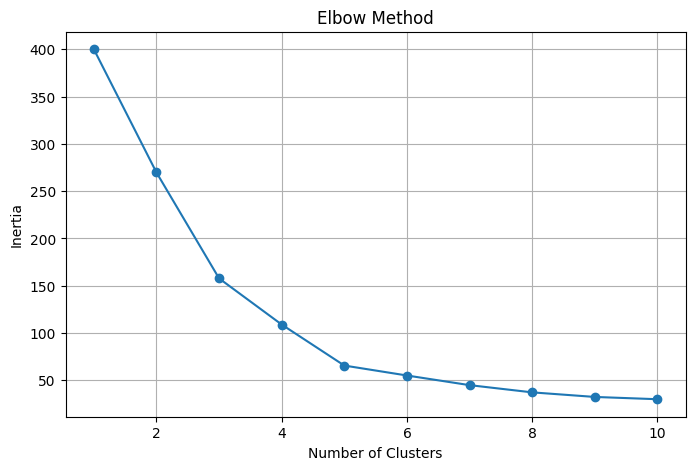

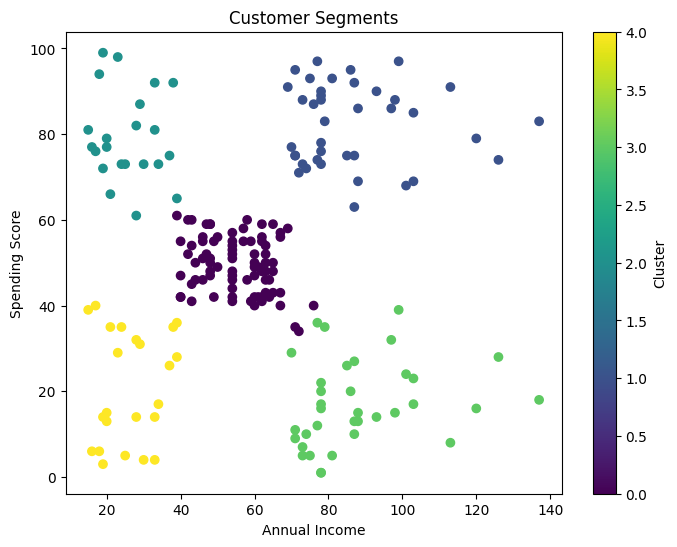

Silhouette Score: 0.5546571631111091
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [18]:
# ===============================
# Task 1: K-Means Clustering
# ===============================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Display first five rows
print(df.head())

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertia = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# Final Model (k = 5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Cluster'],
            cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.colorbar(label="Cluster")
plt.show()

# Silhouette Score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

# Cluster Summary
summary = df.groupby("Cluster")[['Annual Income (k$)',
                                 'Spending Score (1-100)']].mean()

print(summary)

Shape of Dataset: (1797, 64)


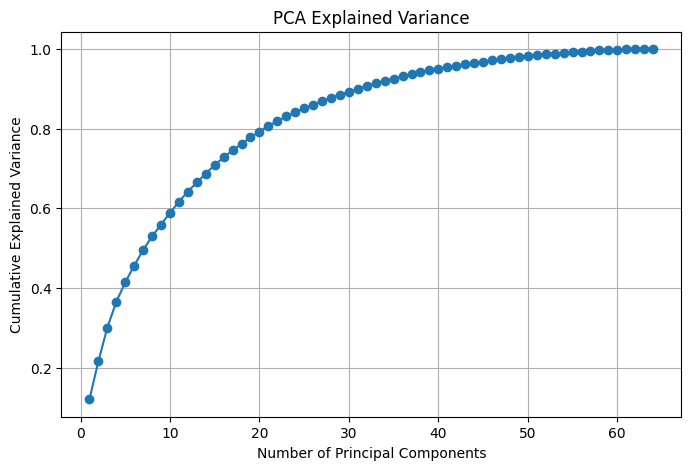

Number of components required to retain 95% variance:
40


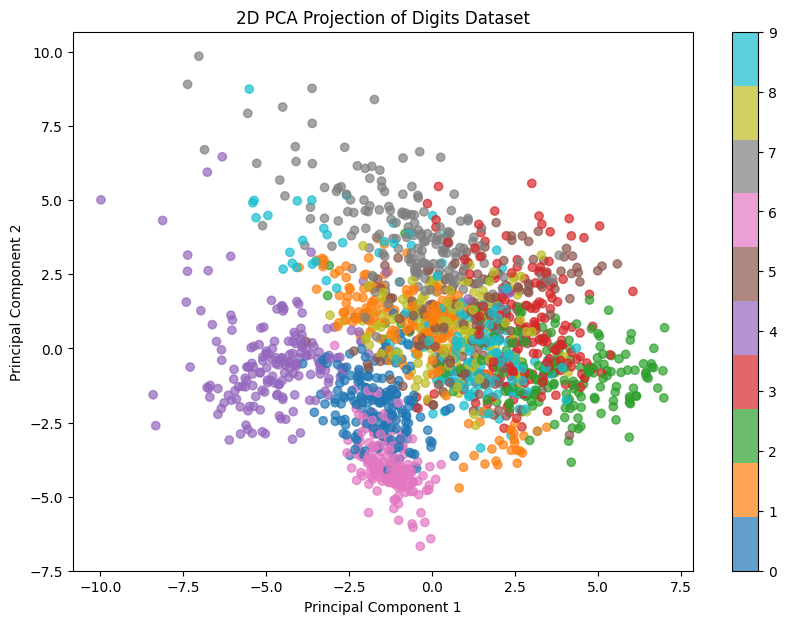

In [19]:
# ==========================================
# Task 2 : PCA - Dimensionality Reduction
# ==========================================

# Import libraries
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Digits Dataset
digits = load_digits()

X = digits.data
y = digits.target

print("Shape of Dataset:", X.shape)

# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained Variance Ratio
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot Explained Variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

# Components required for 95% variance
pca95 = PCA(n_components=0.95)
X95 = pca95.fit_transform(X_scaled)

print("Number of components required to retain 95% variance:")
print(pca95.n_components_)

# Reduce to 2 Components
pca2 = PCA(n_components=2)
X2 = pca2.fit_transform(X_scaled)

# Scatter Plot
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X2[:,0],
    X2[:,1],
    c=y,
    cmap='tab10',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of Digits Dataset")

plt.colorbar(scatter)
plt.show()

### PCA Visualization - Visual Cluster Distinguishability

Based on the 2D PCA projection of the Digits Dataset, the different digit clusters appear **somewhat distinguishable**, but there is significant **overlap** between several clusters.

Observations:
- Some clusters, particularly those representing digits like '0' and '1', show relatively clear separation from others.
- However, many other digit clusters (e.g., '3', '5', '8', '9') are heavily intertwined, making it difficult to precisely delineate boundaries between them based solely on these two principal components.
- The plot indicates that while PCA successfully reduces dimensionality and highlights some underlying structure, two principal components are not sufficient to achieve perfect linear separability for all digit classes.
- This overlap suggests that a classifier relying only on these two components would likely experience some misclassifications, especially for digits within overlapping regions.

In [20]:
# ============================================
# Task 3: Final Project - Initial EDA
# ============================================

# 1. Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Load your actual preprocessed Ames Housing data
house = pd.read_csv('/content/drive/MyDrive/UzmaFatima_ML_Internship/train.csv')

# Display first five rows
house.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [21]:
# Shape of dataset
print("Shape of Dataset:", house.shape)

# Column Names
print("\nFeatures:\n")
print(house.columns.tolist())

# Target Variable
print("\nTarget Variable:", "SalePrice")

# Data Types
house.info()

# Statistical Summary
house.describe()

Shape of Dataset: (1460, 81)

Features:

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPo

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


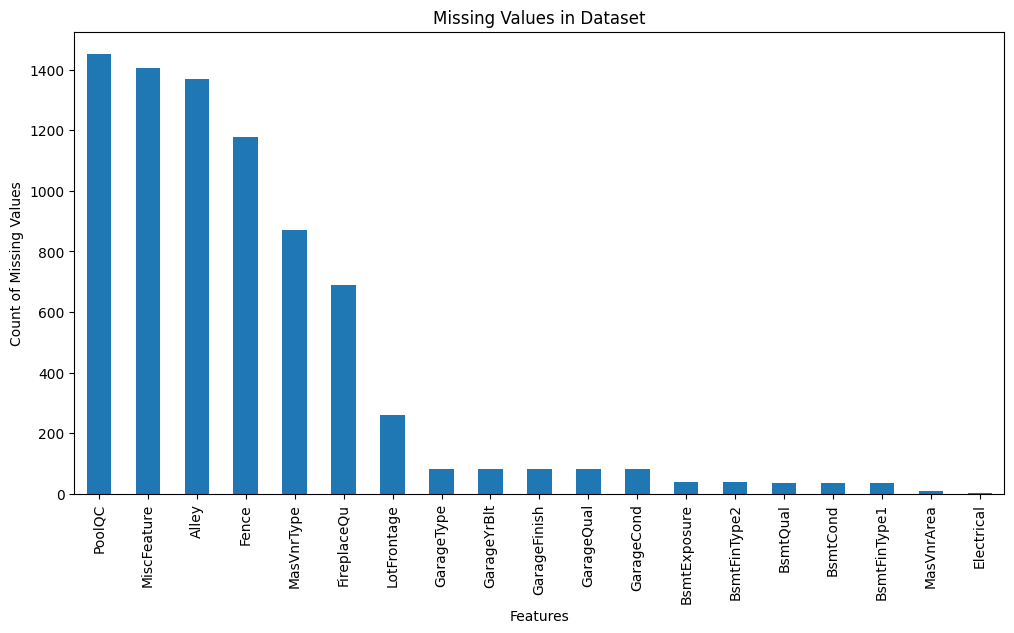

In [22]:
# Missing Values

missing = house.isnull().sum()

missing = missing[missing > 0]

missing = missing.sort_values(ascending=False)

print(missing)

plt.figure(figsize=(12,6))

missing.plot(kind='bar')

plt.title("Missing Values in Dataset")
plt.xlabel("Features")
plt.ylabel("Count of Missing Values")

plt.xticks(rotation=90)

plt.show()

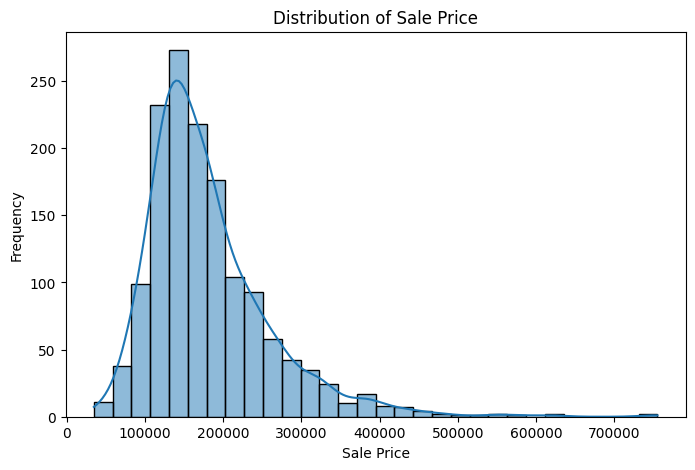

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(house['SalePrice'],
             bins=30,
             kde=True)

plt.title("Distribution of Sale Price")

plt.xlabel("Sale Price")

plt.ylabel("Frequency")

plt.show()

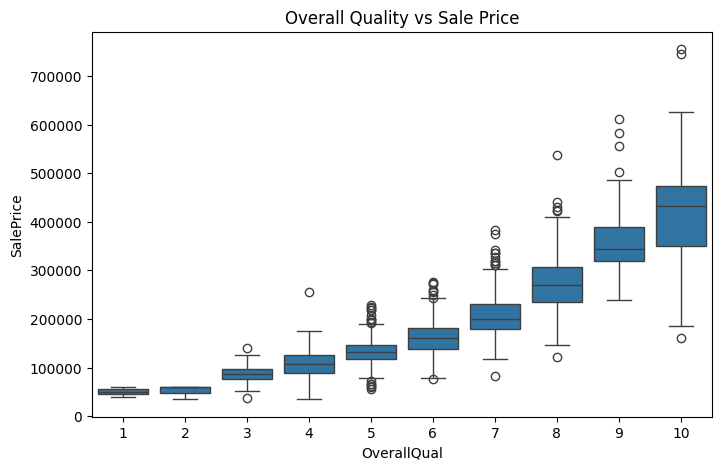

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='OverallQual',
    y='SalePrice',
    data=house
)

plt.title("Overall Quality vs Sale Price")

plt.show()

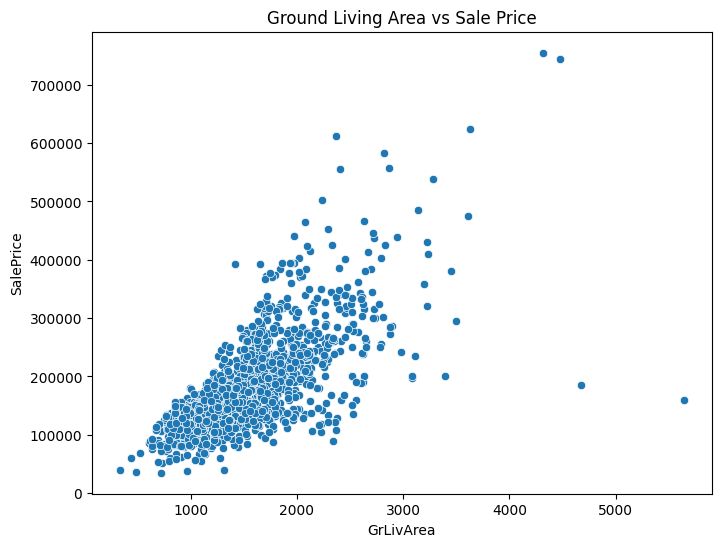

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='GrLivArea',
    y='SalePrice',
    data=house
)

plt.title("Ground Living Area vs Sale Price")

plt.show()

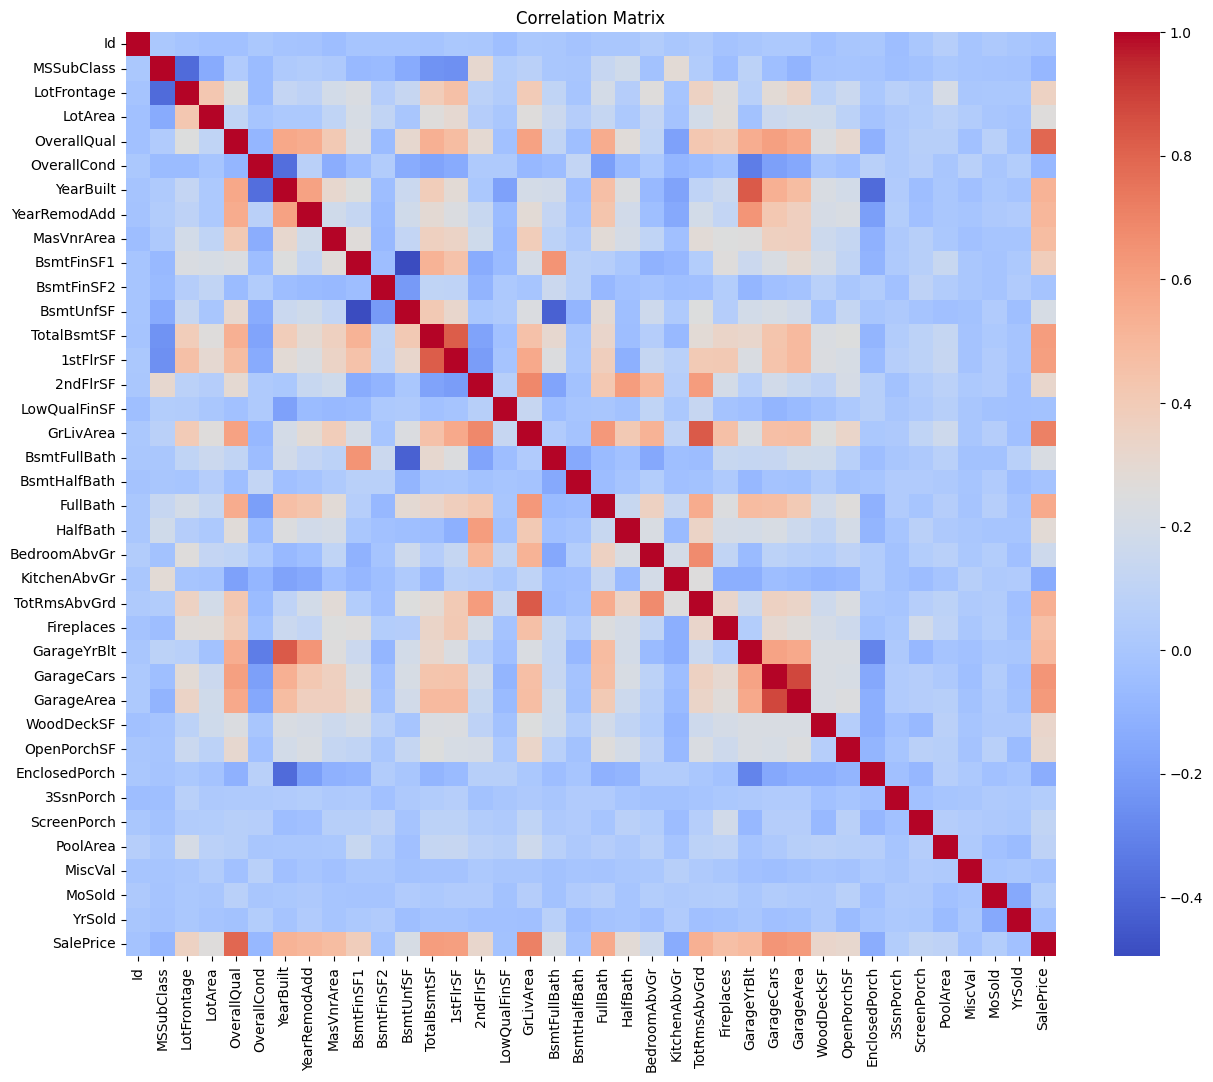

In [26]:
# Select only numeric columns

numeric = house.select_dtypes(include=np.number)

plt.figure(figsize=(15,12))

corr = numeric.corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [27]:
corr_target = numeric.corr()['SalePrice'].sort_values(ascending=False)

print(corr_target.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


In [28]:
print("Skewness of SalePrice:", house['SalePrice'].skew())

print("Kurtosis of SalePrice:", house['SalePrice'].kurt())

Skewness of SalePrice: 1.8828757597682129
Kurtosis of SalePrice: 6.536281860064529


## Project Proposal: House Price Prediction

### 1. Project Title
House Price Prediction using Machine Learning

### 2. Introduction
This project aims to develop a robust machine learning model to accurately predict house sale prices using the Ames Housing Dataset. Accurate price prediction is crucial for various stakeholders, including real estate agents, buyers, sellers, and financial institutions, enabling informed decision-making in the housing market.

### 3. Dataset Description
The project utilizes the `train.csv` dataset, commonly known as the Ames Housing Dataset. This dataset contains 1460 observations with 81 features describing various aspects of residential homes in Ames, Iowa. The features encompass a wide range of information, including:
*   **Location and Zoning**: Neighborhood, MSZoning, LotFrontage, LotArea.
*   **Property Characteristics**: HouseStyle, OverallQual, OverallCond, YearBuilt, YearRemodAdd.
*   **Structural Elements**: BsmtQual, TotalBsmtSF, 1stFlrSF, GrLivArea, FullBath, BedroomAbvGr, KitchenQual.
*   **Garage and Outdoor Features**: GarageType, GarageCars, GarageArea, WoodDeckSF, OpenPorchSF.
*   **Miscellaneous**: PoolArea, Fence, MiscFeature.

The target variable for prediction is `SalePrice`, which represents the actual selling price of each home. The dataset includes both numerical and categorical features, many of which contain missing values that will require careful handling.

### 4. Prediction Goal
The primary goal of this project is to predict the `SalePrice` of houses as accurately as possible. This is a regression problem where the model will learn from the provided features to estimate the continuous `SalePrice` value for new, unseen house data. The success of the model will be evaluated based on metrics such as Root Mean Squared Error (RMSE) and R-squared.

### 5. Planned Approach
Our approach to building the house price prediction model will involve several key stages:

#### 5.1. Data Preprocessing and Cleaning
*   **Handling Missing Values**: Identify and address missing data. Strategies may include imputation (e.g., mean, median, mode for numerical; most frequent for categorical) or dropping columns with excessive missing values (e.g., `PoolQC`, `MiscFeature`, `Alley`).
*   **Feature Engineering**: Create new features from existing ones to potentially improve model performance. Examples include:
    *   `TotalSF`: Sum of various floor areas (e.g., `1stFlrSF`, `2ndFlrSF`, `TotalBsmtSF`).
    *   `YearsSinceRemodel` or `AgeOfHouse`.
    *   Interactions between important features.
*   **Encoding Categorical Variables**: Convert categorical features into numerical representations suitable for machine learning algorithms. Techniques like one-hot encoding or label encoding will be considered.
*   **Outlier Detection and Treatment**: Identify and potentially handle outliers in key numerical features that could skew model training.
*   **Feature Scaling**: Standardize or normalize numerical features to ensure that no single feature dominates the learning process, especially for algorithms sensitive to feature scales (e.g., StandardScaler for tree-based models or models using gradient descent).

#### 5.2. Exploratory Data Analysis (EDA)
*   **Univariate Analysis**: Analyze distributions of individual features, especially `SalePrice` (e.g., histograms, box plots, skewness, kurtosis). Log transformation of `SalePrice` might be necessary to achieve a more normal distribution.
*   **Bivariate Analysis**: Examine relationships between features and the target variable (`SalePrice`), and between features themselves (e.g., scatter plots, correlation matrices, heatmaps).
*   **Multivariate Analysis**: Explore interactions between multiple features.

#### 5.3. Model Selection and Training
*   **Candidate Models**: We will consider a range of regression models, including:
    *   **Linear Models**: Linear Regression, Ridge, Lasso (for regularization and feature selection).
    *   **Tree-based Models**: Decision Trees, Random Forests, Gradient Boosting Machines (e.g., XGBoost, LightGBM).
    *   **Ensemble Methods**: Stacking or blending multiple models.
*   **Cross-Validation**: Utilize k-fold cross-validation to get a more reliable estimate of model performance and prevent overfitting.
*   **Hyperparameter Tuning**: Employ techniques like GridSearchCV or RandomizedSearchCV to optimize model hyperparameters.

#### 5.4. Model Evaluation
*   **Metrics**: The primary evaluation metric will be Root Mean Squared Error (RMSE), as it penalizes large errors more and is interpretable in the same units as the target variable. R-squared will also be used to understand the proportion of variance in the dependent variable that is predictable from the independent variables.
*   **Residual Analysis**: Analyze the residuals (differences between actual and predicted prices) to check for patterns, heteroscedasticity, or uncaptured information.

### 6. Conclusion
By following this structured approach, we aim to develop an accurate and interpretable machine learning model for house price prediction, providing valuable insights and a reliable tool for real estate valuation.

## Observations

1. The dataset contains 1460 rows and multiple explanatory features.

2. SalePrice is the target variable.

3. Several features contain missing values, especially PoolQC, Alley, Fence, FireplaceQu, and MiscFeature.

4. The SalePrice distribution is positively skewed.

5. Houses with higher OverallQual generally have higher SalePrice.

6. Ground Living Area (GrLivArea) has a strong positive relationship with SalePrice.

7. The correlation heatmap indicates that OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, and 1stFlrSF are among the most influential features.

These observations provide a strong starting point for feature engineering and regression modeling.

# Task 4: Capstone Reflection

Over the past eight weeks of this Machine Learning Internship, I have gained a strong understanding of the fundamental concepts of machine learning and how they are applied to real-world problems. The internship started with Python programming and gradually progressed to data preprocessing, exploratory data analysis, supervised learning, model evaluation, feature engineering, and finally unsupervised learning and dimensionality reduction using PCA. Each week introduced new concepts that built upon the previous week's learning, making the overall experience structured and practical.

One of the most challenging topics for me was understanding how machine learning algorithms make predictions and how different evaluation metrics should be interpreted. Initially, concepts like overfitting, cross-validation, feature scaling, and hyperparameter tuning seemed confusing. However, by practicing with multiple datasets, experimenting with different models, and carefully analyzing the outputs, I gradually developed confidence in applying these techniques correctly.

The internship also improved my programming skills in Python and strengthened my knowledge of libraries such as NumPy, Pandas, Matplotlib, Seaborn, and Scikit-learn. I learned how to clean datasets, handle missing values, visualize data effectively, build regression and classification models, evaluate model performance, perform clustering using K-Means, and reduce dimensionality using Principal Component Analysis (PCA).

Working on different assignments helped me understand that data preprocessing and feature engineering are often more important than simply selecting a machine learning algorithm. I also realized the importance of exploratory data analysis in understanding the dataset before building predictive models.

The final project on House Price Prediction allowed me to combine everything I learned during the internship. It helped me understand how machine learning projects are performed from data collection and preprocessing to visualization and model development.

 After completing this internship, I would like to learn more about Deep Learning and Neural Networks.I plan to continue improving my data science and machine learning skills by working on more real-world projects and participating in hackathons. Overall, this internship has provided me with a solid foundation in machine learning and increased my confidence in applying these concepts to practical problems.

#One ML Concept I Want to Learn More About
Deep Learning and Neural Networks